#Analisis exploratorio de los datos de satelites Starlink extraidos de la API de Space-X. Hay una relación entre los parametros de orbita y el tiempo que un satelite permanece en orbita / la salida del orbite de un satelite?

In [1]:
#import libraries

import pandas as pd
import numpy as np
import os
import requests
import datetime
import matplotlib.pyplot as plt
from matplotlib import ticker

import seaborn as sns
sns.set()


import warnings
warnings.filterwarnings("ignore")

In [2]:
#save URL for API call and the output from the API

url_starlink_sats = 'https://api.spacexdata.com/v4/starlink'
res_starlink_sats = requests.get(url = url_starlink_sats)
satellites = res_starlink_sats.json()

In [3]:
satellites

[{'spaceTrack': {'CCSDS_OMM_VERS': '2.0',
   'COMMENT': 'GENERATED VIA SPACE-TRACK.ORG API',
   'CREATION_DATE': '2020-10-13T04:16:08',
   'ORIGINATOR': '18 SPCS',
   'OBJECT_NAME': 'STARLINK-30',
   'OBJECT_ID': '2019-029K',
   'CENTER_NAME': 'EARTH',
   'REF_FRAME': 'TEME',
   'TIME_SYSTEM': 'UTC',
   'MEAN_ELEMENT_THEORY': 'SGP4',
   'EPOCH': '2020-10-13T02:56:59.566560',
   'MEAN_MOTION': 16.43170483,
   'ECCENTRICITY': 0.0003711,
   'INCLINATION': 52.9708,
   'RA_OF_ASC_NODE': 332.0356,
   'ARG_OF_PERICENTER': 120.7278,
   'MEAN_ANOMALY': 242.0157,
   'EPHEMERIS_TYPE': 0,
   'CLASSIFICATION_TYPE': 'U',
   'NORAD_CAT_ID': 44244,
   'ELEMENT_SET_NO': 999,
   'REV_AT_EPOCH': 7775,
   'BSTAR': 0.0022139,
   'MEAN_MOTION_DOT': 0.47180237,
   'MEAN_MOTION_DDOT': 1.2426e-05,
   'SEMIMAJOR_AXIS': 6535.519,
   'PERIOD': 87.635,
   'APOAPSIS': 159.809,
   'PERIAPSIS': 154.958,
   'OBJECT_TYPE': 'PAYLOAD',
   'RCS_SIZE': 'LARGE',
   'COUNTRY_CODE': 'US',
   'LAUNCH_DATE': '2019-05-24',
   'S

In [4]:
#convert the output from the API into a dataframe
df = pd.DataFrame(satellites)
# The SpaceTrack data is nested inside each satellite JSON. Unnesting the SpaceTrack data

if 'spaceTrack' in df.columns:
    # Extract the nested spaceTrack dictionaries into separate columns
    space_track_df = pd.json_normalize(df['spaceTrack'])
    
    # Drop the original spaceTrack column 
    df = df.drop('spaceTrack', axis=1)
    
    # Combine the two dataframes
    df = pd.concat([df, space_track_df], axis=1)

# Now I have a DataFrame with each satellite as a row and each key from JSON as a column

df.head()

,launch,version,height_km,latitude,longitude,velocity_kms,id,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,...,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,DECAYED,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
0,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e59000698560d,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-10-13T04:16:08,...,US,2019-05-24,AFETR,2020-10-13,1,2850561,163365918,0 STARLINK-30,1 44244U 19029K 20287.12291165 .47180237 1...,2 44244 52.9708 332.0356 0003711 120.7278 242...
1,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e59000698560e,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-09-28T19:26:08,...,US,2019-05-24,AFETR,2020-09-29,1,2837086,162391575,0 STARLINK-74,1 44293U 19029BL 20272.77440637 .11359350 1...,2 44293 52.9971 48.1405 0002076 323.1313 37...
2,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e59000698560f,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-10-13T17:46:09,...,US,2019-05-24,AFETR,2020-10-13,1,2851295,163381397,0 STARLINK-29,1 44243U 19029J 20287.71504568 .11982673 1...,2 44243 52.9786 228.8138 0008105 330.1078 31...
3,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e590006985610,2.0,GENERATED VIA SPACE-TRACK.ORG API,2021-09-26T14:36:11,...,US,2019-05-24,AFETR,2021-09-26,1,3129087,185524941,0 STARLINK-76,1 44287U 19029BE 21269.58650490 .32671130 1...,2 44287 52.9578 116.7260 0003663 96.3451 319...
4,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e590006985611,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-09-02T18:57:38,...,US,2019-05-24,AFETR,2020-09-02,1,2813120,160599026,0 STARLINK-23,1 44237U 19029C 20246.24351608 +.23336896 +1...,2 44237 052.9945 186.9776 0004551 271.9057 198...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   launch               3215 non-null   object 
 1   version              3215 non-null   object 
 2   height_km            3268 non-null   float64
 3   latitude             3268 non-null   float64
 4   longitude            3268 non-null   float64
 5   velocity_kms         3268 non-null   float64
 6   id                   3526 non-null   object 
 7   CCSDS_OMM_VERS       3526 non-null   object 
 8   COMMENT              3526 non-null   object 
 9   CREATION_DATE        3526 non-null   object 
 10  ORIGINATOR           3526 non-null   object 
 11  OBJECT_NAME          3526 non-null   object 
 12  OBJECT_ID            3526 non-null   object 
 13  CENTER_NAME          3526 non-null   object 
 14  REF_FRAME            3526 non-null   object 
 15  TIME_SYSTEM          3526 non-null   o

In [5]:
#backfill NaNs in Site so I can use it in feature engineering
df['SITE']=df['SITE'].bfill()

In [6]:
#FEATURE ENGINEERING
# Create the 'SITE_NUM' numerical column for Air base where satelite is launched from using np.where: 0- West Vandenberg, Santa Barbara,CA, 1- East, Cape Cnaveral
df['SITE_NUM'] = np.where(df['SITE'] == 'AFWTR', 0, 1)

In [7]:
#how many sats were launched from the west ?
count_west = (df['SITE_NUM'] == 0).sum()
print(count_west)

497


In [8]:
#how many sats were launched from the east ?
count_east = df['SITE_NUM'].value_counts().get(1, 0)
print(count_east)

3029


In [9]:
#check how many NaN in each column
df.isna().sum()

launch                  311
version                 311
height_km               258
latitude                258
longitude               258
velocity_kms            258
id                        0
CCSDS_OMM_VERS            0
COMMENT                   0
CREATION_DATE             0
ORIGINATOR                0
OBJECT_NAME               0
OBJECT_ID                 0
CENTER_NAME               0
REF_FRAME                 0
TIME_SYSTEM               0
MEAN_ELEMENT_THEORY       0
EPOCH                     0
MEAN_MOTION               0
ECCENTRICITY              0
INCLINATION               0
RA_OF_ASC_NODE            0
ARG_OF_PERICENTER         0
MEAN_ANOMALY              0
EPHEMERIS_TYPE            0
CLASSIFICATION_TYPE       0
NORAD_CAT_ID              0
ELEMENT_SET_NO            0
REV_AT_EPOCH              0
BSTAR                     0
MEAN_MOTION_DOT           0
MEAN_MOTION_DDOT          0
SEMIMAJOR_AXIS            0
PERIOD                    0
APOAPSIS                  0
PERIAPSIS           

,launch,version,height_km,latitude,longitude,velocity_kms,id,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,...,LAUNCH_DATE,SITE,DECAY_DATE,DECAYED,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,SITE_NUM
2042,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40bd,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T06:56:12,...,None,AFETR,2022-02-07,1,3293121,195380770,0 STARLINK-3XXX,1 51459U 22010D 22037.23001983 .03586192 1...,2 51459 53.2230 161.6012 0071354 169.6697 190...,1
2043,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40be,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T00:46:11,...,None,AFETR,2022-02-08,1,3293008,195378552,0 STARLINK-3XXX,1 51457U 22010B 22037.00001157 -.00956184 3...,2 51457 53.2173 162.8217 0078778 164.2324 275...,1
2044,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40ce,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T00:46:11,...,None,AFETR,2022-02-06,1,3293005,195378555,0 STARLINK-3XXX,1 51458U 22010C 22037.00001157 -.00957341 3...,2 51458 53.2173 162.8262 0079772 163.8403 273...,1
2045,None,None,NaN,NaN,NaN,NaN,620190a6a8973c1694b4fcda,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T18:07:45,...,None,AFETR,2022-02-06,1,3293555,195415050,0 STARLINK-3XXX,1 51456U 22010A 22037.59202951 .49730979 1...,2 51456 53.2082 159.5480 0015581 174.4115 185...,1
2046,None,None,NaN,NaN,NaN,NaN,6204097da8973c1694c6a3d9,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-09T01:36:12,...,None,AFETR,2022-02-09,1,3295469,195581643,0 STARLINK-3XXX,1 51466U 22010L 22039.46449989 -.00003746 1...,2 51466 53.2042 149.8871 0044415 182.9144 177...,1


In [12]:
#'RCS_SIZE' also has a few nulls and I am going to use it in feature engineering. I will backfill the nulls
df['RCS_SIZE']=df['RCS_SIZE'].bfill()


In [13]:
#FEATURE ENGINEERING
# Create the 'RCS_SIZE_NUM' numerical column 0- MEDIUM 1- LARGE
df['RCS_SIZE_NUM']= np.where(df['RCS_SIZE'] == 'MEDIUM', 0, 1)
df['RCS_SIZE_NUM'].unique()

array([1, 0])

In [14]:
count_medium = (df['RCS_SIZE_NUM'] == 0).sum()
print(count_medium)

69


In [15]:
count_large = (df['RCS_SIZE_NUM'] == 1).sum()
print(count_large)

3457


In [16]:
df[['DECAY_DATE','DECAYED','LAUNCH_DATE']]

,DECAY_DATE,DECAYED,LAUNCH_DATE
0,2020-10-13,1,2019-05-24
1,2020-09-29,1,2019-05-24
2,2020-10-13,1,2019-05-24
3,2021-09-26,1,2019-05-24
4,2020-09-02,1,2019-05-24
...,...,...,...
3521,None,0,2022-10-28
3522,None,0,2022-10-28
3523,None,0,2022-10-28
3524,None,0,2022-10-28


In [17]:
#features engineering
#I want to create a column for days in orbit. First I need to make sure that decay_date and launch_date are actually correct data types
from datetime import datetime

# Convert date columns to datetime
df['LAUNCH_DATE'] = pd.to_datetime(df['LAUNCH_DATE'])

# Convert DECAY_DATE to datetime, but keep NaN values as NaN
df['DECAY_DATE'] = pd.to_datetime(df['DECAY_DATE'], errors='coerce')

# Get current date for satellites still in orbit
current_date = pd.Timestamp.now().floor('D')  # Floor to remove time component

# Calculate days in orbit
# For decayed satellites: DECAY_DATE - LAUNCH_DATE
# For active satellites: current_date - LAUNCH_DATE
df['DAYS_ORBIT'] = df.apply(
    lambda row: (row['DECAY_DATE'] - row['LAUNCH_DATE']).days if pd.notna(row['DECAY_DATE']) 
    else (current_date - row['LAUNCH_DATE']).days, 
    axis=1
)

In [21]:
df[['DAYS_ORBIT','BSTAR','LAUNCH_DATE']].describe()

,DAYS_ORBIT,BSTAR,LAUNCH_DATE
count,3521.000000,3526.000000,3521
mean,1231.865379,-0.001121,2021-08-03 12:07:58.500425984
min,7.000000,-0.075593,2018-02-22 00:00:00
25%,969.000000,0.000004,2020-10-24 00:00:00
50%,1168.000000,0.000062,2021-09-14 00:00:00
75%,1504.000000,0.000139,2022-06-17 00:00:00
max,1955.000000,0.008197,2022-10-28 00:00:00
std,384.549834,0.007950,NaN


In [23]:
df[['DAYS_ORBIT','LAUNCH_DATE']].isna().sum()

DAYS_ORBIT     5
LAUNCH_DATE    5
dtype: int64

In [25]:
df[['DECAY_DATE','DECAYED','LAUNCH_DATE', 'DAYS_ORBIT']]

,DECAY_DATE,DECAYED,LAUNCH_DATE,DAYS_ORBIT
0,2020-10-13,1,2019-05-24,508.0
1,2020-09-29,1,2019-05-24,494.0
2,2020-10-13,1,2019-05-24,508.0
3,2021-09-26,1,2019-05-24,856.0
4,2020-09-02,1,2019-05-24,467.0
...,...,...,...,...
3521,NaT,0,2022-10-28,871.0
3522,NaT,0,2022-10-28,871.0
3523,NaT,0,2022-10-28,871.0
3524,NaT,0,2022-10-28,871.0


In [24]:
#There's missing values in 'LAUNCH_DATE' which I'm using for feature engineering
df.loc[df['LAUNCH_DATE'].isnull()]

,launch,version,height_km,latitude,longitude,velocity_kms,id,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,...,DECAY_DATE,DECAYED,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,SITE_NUM,RCS_SIZE_NUM,DAYS_ORBIT
2042,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40bd,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T06:56:12,...,2022-02-07,1,3293121,195380770,0 STARLINK-3XXX,1 51459U 22010D 22037.23001983 .03586192 1...,2 51459 53.2230 161.6012 0071354 169.6697 190...,1,1,NaN
2043,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40be,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T00:46:11,...,2022-02-08,1,3293008,195378552,0 STARLINK-3XXX,1 51457U 22010B 22037.00001157 -.00956184 3...,2 51457 53.2173 162.8217 0078778 164.2324 275...,1,1,NaN
2044,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40ce,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T00:46:11,...,2022-02-06,1,3293005,195378555,0 STARLINK-3XXX,1 51458U 22010C 22037.00001157 -.00957341 3...,2 51458 53.2173 162.8262 0079772 163.8403 273...,1,1,NaN
2045,None,None,NaN,NaN,NaN,NaN,620190a6a8973c1694b4fcda,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T18:07:45,...,2022-02-06,1,3293555,195415050,0 STARLINK-3XXX,1 51456U 22010A 22037.59202951 .49730979 1...,2 51456 53.2082 159.5480 0015581 174.4115 185...,1,1,NaN
2046,None,None,NaN,NaN,NaN,NaN,6204097da8973c1694c6a3d9,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-09T01:36:12,...,2022-02-09,1,3295469,195581643,0 STARLINK-3XXX,1 51466U 22010L 22039.46449989 -.00003746 1...,2 51466 53.2042 149.8871 0044415 182.9144 177...,1,1,NaN


In [59]:
#display candidates for deorbit
candidates_deorbit = df.loc[[3331, 3424, 3452, 3461, 3489],['GP_ID', 'TLE_LINE0', 'DAYS_ORBIT']]

# Display the result
candidates_deorbit

,GP_ID,TLE_LINE0,DAYS_ORBIT
3331,219178341,0 STARLINK-5021,907.0
3424,219178195,0 STARLINK-5197,881.0
3452,219177325,0 STARLINK-5172,881.0
3461,219177330,0 STARLINK-5203,881.0
3489,219177696,0 STARLINK-5182,873.0


In [25]:

#missing launch dates are all for decayed satelites. I will just fill DAYS_ORBIT with median of this value for decayed satelites
# Calculate the median DAYS_ORBIT for decayed satellites
decayed_median_days = df[df['DECAYED'] == 1]['DAYS_ORBIT'].median()

# Fill the missing values in DAYS_ORBIT with this median
df['DAYS_ORBIT'] = df['DAYS_ORBIT'].fillna(decayed_median_days)

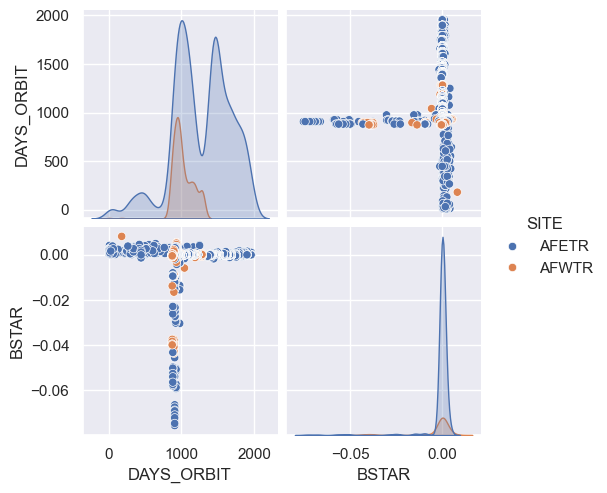

In [26]:
#pairplot basic relationships

sns.pairplot(df[['DAYS_ORBIT','BSTAR','SITE']],hue='SITE',diag_kind='kde')



<Axes: xlabel='DAYS_ORBIT', ylabel='Count'>

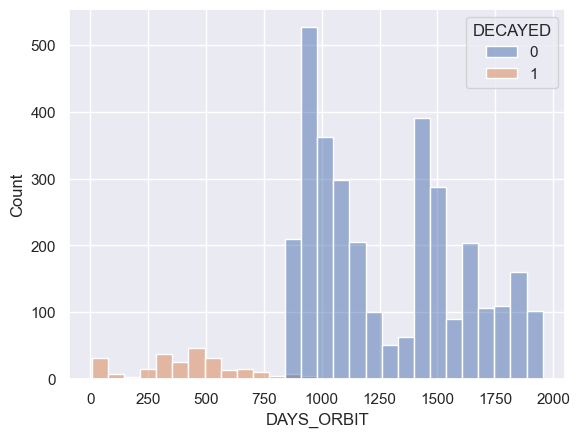

In [27]:
sns.histplot(data=df, x='DAYS_ORBIT', hue='DECAYED')

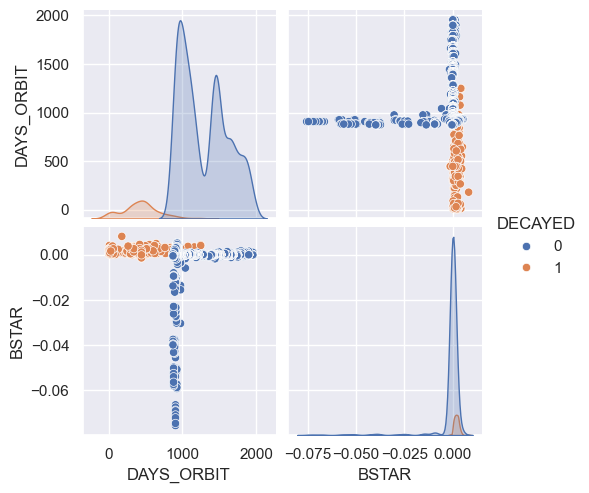

In [28]:
sns.pairplot(df[['DAYS_ORBIT','BSTAR','DECAYED']],hue='DECAYED',diag_kind='kde')

In [29]:
#select numeric columns

df_num=df.select_dtypes('number')

In [30]:
df_num.describe()

,height_km,latitude,longitude,velocity_kms,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,...,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,FILE,GP_ID,SITE_NUM,RCS_SIZE_NUM,DAYS_ORBIT
count,3268.000000,3268.000000,3268.000000,3268.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,...,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3.526000e+03,3.526000e+03,3526.000000,3526.000000,3526.000000
mean,539.588682,1.321539,2.248772,7.594950,15.205655,0.000268,55.884862,175.859229,76.763091,274.190037,...,6884.325872,94.752176,508.013938,504.367812,0.073171,3.639188e+06,2.167925e+08,0.859047,0.980431,1230.750993
std,45.941995,37.061888,102.982183,0.026316,0.362179,0.000361,10.410713,102.320278,68.748335,75.839360,...,103.933078,2.124299,102.701246,105.203804,0.260453,1.464317e+05,9.705201e+06,0.348022,0.138533,385.413521
min,303.137599,-82.237072,-179.933614,7.561740,14.980207,0.000022,52.942000,0.079000,0.049500,0.214500,...,6499.858000,86.919000,125.504000,99.974000,0.000000,2.706890e+06,1.491550e+08,0.000000,0.000000,7.000000
25%,543.024058,-32.992599,-86.384518,7.582612,15.063925,0.000161,53.054900,90.177325,43.042975,282.043250,...,6917.882000,95.438000,541.123000,537.861000,0.000000,3.674952e+06,2.191366e+08,1.000000,1.000000,969.000000
50%,549.031323,2.244397,1.907842,7.591027,15.088160,0.000193,53.212650,174.155950,57.935750,299.933700,...,6917.954000,95.439000,541.971500,538.717500,0.000000,3.675646e+06,2.191735e+08,1.000000,1.000000,1168.000000
75%,556.617742,36.505165,91.000716,7.595025,15.088396,0.000263,53.217600,261.441650,73.161325,315.514475,...,6925.371750,95.593000,548.409000,546.105750,0.000000,3.675646e+06,2.191764e+08,1.000000,1.000000,1504.000000
max,595.373243,82.297000,179.973121,7.729005,16.567117,0.007977,97.661600,359.927700,359.907900,359.937300,...,6951.150000,96.127000,575.953000,570.256000,1.000000,3.675646e+06,2.191784e+08,1.000000,1.000000,1955.000000


In [31]:
list(df_num.columns.values)

['height_km',
 'latitude',
 'longitude',
 'velocity_kms',
 'MEAN_MOTION',
 'ECCENTRICITY',
 'INCLINATION',
 'RA_OF_ASC_NODE',
 'ARG_OF_PERICENTER',
 'MEAN_ANOMALY',
 'EPHEMERIS_TYPE',
 'NORAD_CAT_ID',
 'ELEMENT_SET_NO',
 'REV_AT_EPOCH',
 'BSTAR',
 'MEAN_MOTION_DOT',
 'MEAN_MOTION_DDOT',
 'SEMIMAJOR_AXIS',
 'PERIOD',
 'APOAPSIS',
 'PERIAPSIS',
 'DECAYED',
 'FILE',
 'GP_ID',
 'SITE_NUM',
 'RCS_SIZE_NUM',
 'DAYS_ORBIT']

In [32]:
#drop GUIDs and variables only available for orbiting satellites such as current velocity and height

df_num=df_num.drop(['FILE',
 'GP_ID', 'NORAD_CAT_ID',
 'ELEMENT_SET_NO', 'latitude',
 'longitude','height_km','velocity_kms'],axis=1)

In [33]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEAN_MOTION        3526 non-null   float64
 1   ECCENTRICITY       3526 non-null   float64
 2   INCLINATION        3526 non-null   float64
 3   RA_OF_ASC_NODE     3526 non-null   float64
 4   ARG_OF_PERICENTER  3526 non-null   float64
 5   MEAN_ANOMALY       3526 non-null   float64
 6   EPHEMERIS_TYPE     3526 non-null   int64  
 7   REV_AT_EPOCH       3526 non-null   int64  
 8   BSTAR              3526 non-null   float64
 9   MEAN_MOTION_DOT    3526 non-null   float64
 10  MEAN_MOTION_DDOT   3526 non-null   float64
 11  SEMIMAJOR_AXIS     3526 non-null   float64
 12  PERIOD             3526 non-null   float64
 13  APOAPSIS           3526 non-null   float64
 14  PERIAPSIS          3526 non-null   float64
 15  DECAYED            3526 non-null   int64  
 16  SITE_NUM           3526 

In [34]:
df_num.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,SITE_NUM,RCS_SIZE_NUM,DAYS_ORBIT
count,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.0,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000
mean,15.205655,0.000268,55.884862,175.859229,76.763091,274.190037,0.0,6781.168746,-0.001121,0.020006,0.000001,6884.325872,94.752176,508.013938,504.367812,0.073171,0.859047,0.980431,1230.750993
std,0.362179,0.000361,10.410713,102.320278,68.748335,75.839360,0.0,4897.957326,0.007950,0.091828,0.000012,103.933078,2.124299,102.701246,105.203804,0.260453,0.348022,0.138533,385.413521
min,14.980207,0.000022,52.942000,0.079000,0.049500,0.214500,0.0,130.000000,-0.075593,-0.012429,0.000000,6499.858000,86.919000,125.504000,99.974000,0.000000,0.000000,0.000000,7.000000
25%,15.063925,0.000161,53.054900,90.177325,43.042975,282.043250,0.0,2341.500000,0.000004,-0.000002,0.000000,6917.882000,95.438000,541.123000,537.861000,0.000000,1.000000,1.000000,969.000000
50%,15.088160,0.000193,53.212650,174.155950,57.935750,299.933700,0.0,5808.500000,0.000062,0.000007,0.000000,6917.954000,95.439000,541.971500,538.717500,0.000000,1.000000,1.000000,1168.000000
75%,15.088396,0.000263,53.217600,261.441650,73.161325,315.514475,0.0,10119.750000,0.000139,0.000019,0.000000,6925.371750,95.593000,548.409000,546.105750,0.000000,1.000000,1.000000,1504.000000
max,16.567117,0.007977,97.661600,359.927700,359.907900,359.937300,0.0,18984.000000,0.008197,1.000000,0.000550,6951.150000,96.127000,575.953000,570.256000,1.000000,1.000000,1.000000,1955.000000


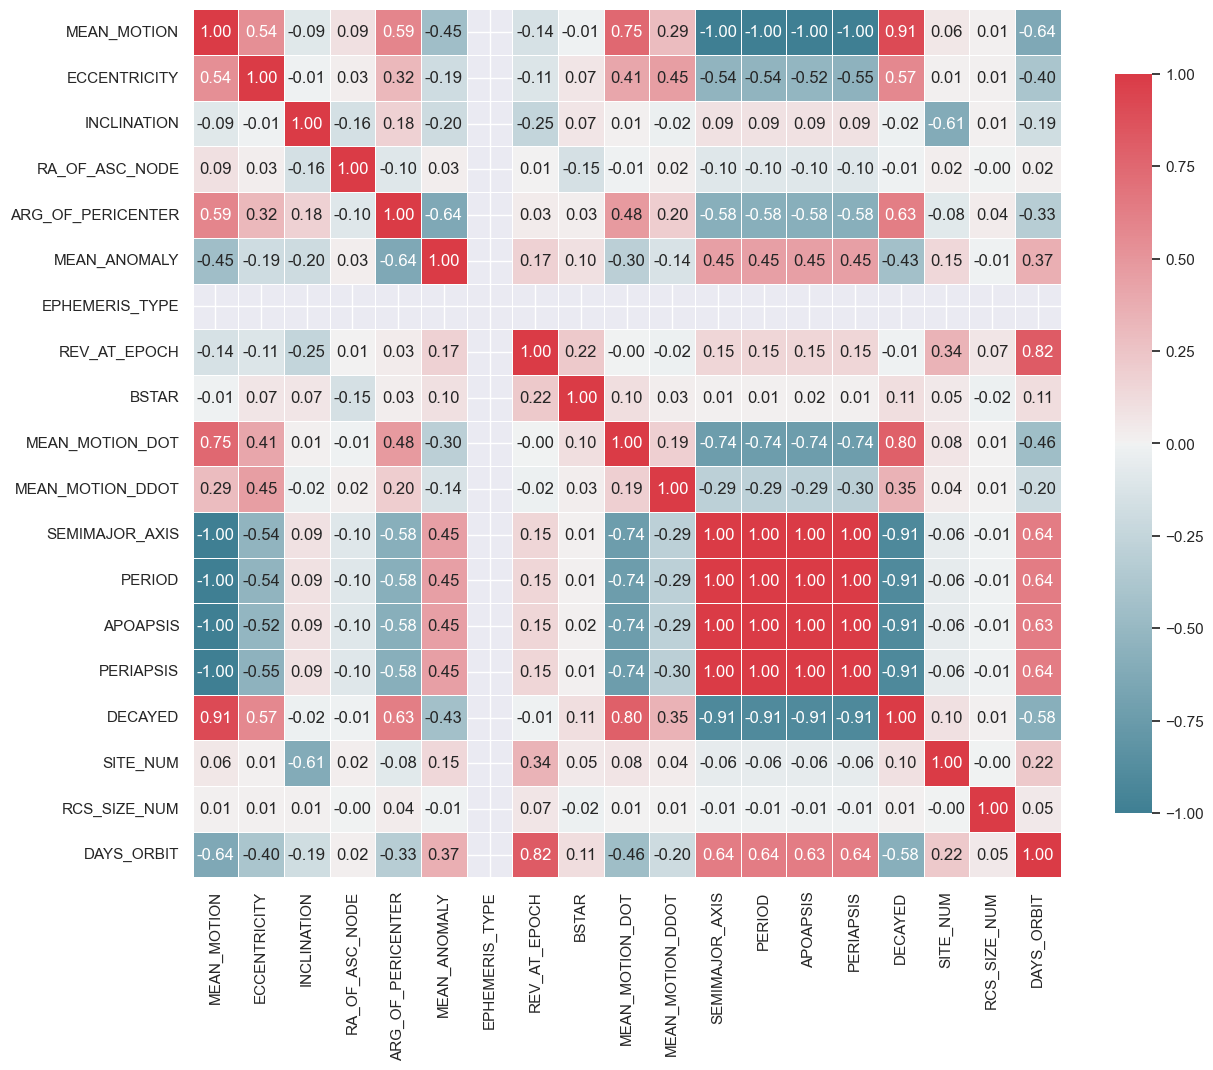

In [35]:
# Calculate the correlation matrix
correlation_matrix = df_num.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Create a custom colormap with dark red for strong positive correlations
cmap = sns.diverging_palette(220, 10, as_cmap=True)

heatmap = sns.heatmap(
    correlation_matrix,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": .8}
)
plt.show()

In [36]:
#Orbit decay derivatives in decayed and not
#rev_at_epoch por dia - if more revs it was launched earlier, total doesn't make sense
df_num.groupby('DECAYED')[['MEAN_MOTION','REV_AT_EPOCH','MEAN_MOTION_DOT','MEAN_MOTION_DDOT','DAYS_ORBIT','SITE_NUM']].agg(['mean','std','count'])

MEAN_MOTION                 REV_AT_EPOCH                     \
               mean       std count         mean          std count   
DECAYED                                                               
0         15.112778  0.151374  3268  6799.387393  4973.929460  3268   
1         16.382098  0.093779   258  6550.399225  3806.803343   258   

        MEAN_MOTION_DOT                 MEAN_MOTION_DDOT                      \
                   mean       std count             mean           std count   
DECAYED                                                                        
0              -0.00052  0.002418  3268     1.187974e-08  6.791224e-07  3268   
1               0.28001  0.205820   258     1.616924e-05  4.212369e-05   258   

          DAYS_ORBIT                    SITE_NUM                  
                mean         std count      mean       std count  
DECAYED                                                           
0        1293.884333  318.017644  3268  0.849143  0.357964  3268  
1         431.062016  243.115855   258  0.984496  0.123786   258

In [37]:
#Orbit params in decayed and not
#encuentra un perfil de los malos, 5 peores satelites activos que se puedan caer en proxi,os dias-percentiles mas bajos/altos - encuentra los match
df_num.groupby('DECAYED')[['SEMIMAJOR_AXIS','PERIOD','APOAPSIS','PERIAPSIS','DAYS_ORBIT','SITE_NUM']].agg(['mean','std','count'])

SEMIMAJOR_AXIS                      PERIOD                  \
                  mean        std count       mean       std count   
DECAYED                                                              
0          6910.812715  44.881103  3268  95.292852  0.923176  3268   
1          6548.825864  25.212397   258  87.903605  0.508551   258   

           APOAPSIS                    PERIAPSIS                   \
               mean        std count        mean        std count   
DECAYED                                                             
0        534.126564  44.673489  3268  531.228874  45.094332  3268   
1        177.254012  28.310569   258  164.127702  23.821691   258   

          DAYS_ORBIT                    SITE_NUM                  
                mean         std count      mean       std count  
DECAYED                                                           
0        1293.884333  318.017644  3268  0.849143  0.357964  3268  
1         431.062016  243.115855   258  0.984496  0.123786   258

In [ ]:
#orbit params detailed pericentiles
df_num.groupby('DECAYED')[['SEMIMAJOR_AXIS','PERIOD','APOAPSIS','PERIAPSIS']].describe(percentiles=[.05,.1,.25, .5, .75,.9,.95])


PERIOD                                                           \
          count       mean       std     min        5%      10%      25%   
DECAYED                                                                    
0        3268.0  95.292852  0.923176  90.547  92.29470  95.4357  95.4380   
1         258.0  87.903605  0.508551  86.919  87.20365  87.3241  87.5865   

                                    ...   APOAPSIS                      \
             50%       75%     90%  ...        std      min         5%   
DECAYED                             ...                                  
0        95.5920  95.59300  95.593  ...  44.673489  305.681  387.84110   
1        87.8825  88.16375  88.430  ...  28.310569  125.504  142.72325   

                                                                                
              10%        25%       50%       75%       90%        95%      max  
DECAYED                                                                         
0        540.4388  541.28275  548.1150  548.4240  548.6733  564.29465  575.953  
1        148.7572  159.87600  174.9855  188.7055  202.4643  210.48870  360.959  

[2 rows x 24 columns]

In [ ]:
#FIND PERICENTILE 5% of the worst orbit params
df_num.loc[(df_num['DECAYED'] == 0) & (df_num['PERIAPSIS'] < 537)& (df_num['SEMIMAJOR_AXIS'] < 6765)&(df_num['PERIOD'] < 92)&(df_num['APOAPSIS'] < 388)]

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,DAYS_ORBIT,RCS_SIZE_NUM,SITE_NUM
874,15.767483,0.000138,53.0465,211.0148,134.4500,225.6633,0,11759,9.612500e-05,0.000151,0.000000,6717.798,91.327,340.587,338.738,0,1605.0,1,1
888,15.767048,0.000097,53.0435,203.9851,72.2449,287.8676,0,11769,-2.428200e-05,-0.000046,0.000000,6717.921,91.330,340.436,339.137,0,1605.0,1,1
1044,15.903322,0.000648,53.0476,207.4911,143.3231,216.8239,0,10258,8.894300e-04,0.002746,0.000039,6679.490,90.547,305.681,297.028,0,1502.0,1,1
1286,15.767245,0.000248,53.0444,131.0936,38.0269,322.0925,0,9705,1.279900e-04,0.000203,0.000000,6717.865,91.329,341.394,338.067,0,1464.0,1,1
1290,15.767221,0.000136,53.0177,343.4284,72.2142,287.9025,0,9969,-1.366600e-07,-0.000007,0.000000,6717.872,91.329,340.649,338.826,0,1464.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3521,15.731703,0.000383,53.2167,337.9278,6.8795,344.8697,0,130,3.509800e-04,0.000489,0.000000,6727.980,91.535,352.422,347.268,0,871.0,1,0
3522,15.732271,0.000371,53.2156,337.8864,4.5467,3.8052,0,130,-3.122600e-04,-0.000443,0.000000,6727.818,91.532,352.176,347.190,0,871.0,1,0
3523,15.732169,0.000442,53.2159,337.9243,3.2523,347.8894,0,130,-5.268600e-04,-0.000740,0.000000,6727.847,91.532,352.688,346.736,0,871.0,1,0
3524,15.732488,0.000414,53.2152,337.9079,1.3558,356.3124,0,130,-6.316200e-04,-0.000886,0.000000,6727.756,91.530,352.408,346.834,0,871.0,1,0


In [93]:
#orbit decay derivatives detailed pericentiles
#df_num.groupby('DECAYED')[['MEAN_MOTION','MEAN_MOTION_DDOT','MEAN_MOTION_DOT','REV_AT_EPOCH']].describe(percentiles=[.05,.1,.25, .5, .75,.9,.95])
df_num.groupby('DECAYED')[['MEAN_MOTION']].describe(percentiles=[.05,.1,.25, .5, .75,.9,.95])

MEAN_MOTION                                                        \
              count       mean       std        min         5%        10%   
DECAYED                                                                     
0            3268.0  15.112778  0.151374  14.980207  15.012588  15.063839   
1             258.0  16.382098  0.093779  15.757463  16.257715  16.284009   

                                                                           
               25%        50%        75%        90%        95%        max  
DECAYED                                                                    
0        15.063919  15.064060  15.088362  15.088713  15.602250  15.903322  
1        16.333194  16.385545  16.440831  16.490295  16.513073  16.567117

In [ ]:
#FIND PERICENTILE 5% of the worst orbit decay derivates
df_num.loc[(df_num['MEAN_MOTION'] >15.6) &(df_num['MEAN_MOTION_DOT'] > 0.000046)&(df_num['REV_AT_EPOCH'] < 131)]


,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,DAYS_ORBIT,RCS_SIZE_NUM,SITE_NUM
3200,15.731781,0.000314,53.2149,202.1848,10.9370,180.5137,0,130,0.000672,0.000947,0.0,6727.958,91.534,351.938,347.707,0,924.0,1,1
3208,15.731989,0.000881,53.2135,205.0857,275.1096,300.5855,0,130,0.000645,0.000910,0.0,6727.898,91.533,355.693,343.834,0,924.0,1,1
3234,15.731811,0.000316,53.2140,231.8872,16.6362,145.3336,0,130,0.000241,0.000333,0.0,6727.949,91.534,351.943,347.685,0,918.0,1,1
3241,15.731927,0.000338,53.2144,228.5869,15.5374,324.9554,0,130,0.000751,0.001062,0.0,6727.916,91.534,352.058,347.504,0,918.0,1,1
3246,15.731765,0.000363,53.2139,231.8882,10.5630,150.8090,0,130,0.000206,0.000283,0.0,6727.962,91.535,352.271,347.383,0,918.0,1,1
3268,15.731779,0.000391,53.2148,259.7702,10.5252,281.6686,0,130,0.000368,0.000514,0.0,6727.958,91.534,352.457,347.189,0,910.0,1,1
3273,15.731724,0.000377,53.2150,259.7725,1.2941,289.1838,0,130,0.000548,0.000769,0.0,6727.974,91.535,352.375,347.302,0,910.0,1,1
3275,15.731813,0.000383,53.2145,259.7743,1.0828,287.6067,0,130,0.000565,0.000793,0.0,6727.948,91.534,352.388,347.239,0,910.0,1,1
3276,15.731860,0.000370,53.2149,258.2711,4.9131,295.9155,0,130,0.000606,0.000852,0.0,6727.935,91.534,352.292,347.308,0,910.0,1,1
3278,15.731697,0.000360,53.2147,259.7670,3.8076,289.6339,0,130,0.000357,0.000498,0.0,6727.982,91.535,352.270,347.423,0,910.0,1,1


In [97]:
#find worst combined orbit and decay among active sats
df_num.loc[(df_num['DECAYED'] == 0) & (df_num['PERIAPSIS'] < 537)& (df_num['SEMIMAJOR_AXIS'] < 6765)&(df_num['PERIOD'] < 92)&(df_num['APOAPSIS'] < 388) &(df_num['MEAN_MOTION_DOT'] > 0.000046)&(df_num['REV_AT_EPOCH'] < 131)&(df_num['MEAN_MOTION'] > 15.732)]

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,DAYS_ORBIT,RCS_SIZE_NUM,SITE_NUM
3331,15.732076,0.000813,53.2150,282.9662,288.5886,310.1094,0,130,0.000212,0.000293,0.0,6727.873,91.533,355.207,344.270,0,905.0,1,1
3424,15.732118,0.000401,53.2154,305.0589,4.0864,226.8526,0,130,0.000103,0.000138,0.0,6727.862,91.532,352.424,347.029,0,879.0,0,1
3452,15.732019,0.000416,53.2150,305.0824,1.9522,214.0082,0,130,0.000105,0.000141,0.0,6727.890,91.533,352.556,346.953,0,879.0,1,1
3461,15.732159,0.000379,53.2149,305.0940,4.3521,210.9991,0,130,0.000065,0.000085,0.0,6727.850,91.532,352.263,347.167,0,879.0,1,1
3489,15.732026,0.000432,53.2159,337.9110,3.2466,355.0242,0,130,0.000336,0.000468,0.0,6727.888,91.533,352.657,346.848,0,871.0,1,0


In [44]:
#cleaner code to find bottom 5% of positively correlated orbital params
# Filter for active satellites only
active_satellites = df_num[df_num['DECAYED'] == 0]

# Calculate the 5th percentile for each parameter among active satellites
percentile_5 = active_satellites[['SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS','REV_AT_EPOCH']].quantile(0.05)

# Find satellites that are in the bottom 5 percentile for all four parameters
bottom_5_percentile = active_satellites[
    (active_satellites['SEMIMAJOR_AXIS'] <= percentile_5['SEMIMAJOR_AXIS']) &
    (active_satellites['PERIOD'] <= percentile_5['PERIOD']) &
    (active_satellites['APOAPSIS'] <= percentile_5['APOAPSIS']) &
    (active_satellites['PERIAPSIS'] <= percentile_5['PERIAPSIS']) & 
    (active_satellites['REV_AT_EPOCH'] <= percentile_5['REV_AT_EPOCH'])
]
bottom_5_percentile


,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,SITE_NUM,RCS_SIZE_NUM,DAYS_ORBIT
2775,15.629264,0.000122,53.2175,93.9490,63.6196,222.6875,0,130,-0.013583,-0.011333,0.0,6757.346,92.135,380.033,378.389,0,1,1,976.0
2778,15.629759,0.000124,53.2175,93.9538,61.3979,222.6782,0,130,-0.013556,-0.011333,0.0,6757.203,92.132,379.906,378.231,0,1,1,976.0
2813,15.628116,0.000123,53.2175,93.9679,60.6827,229.1032,0,130,-0.013646,-0.011334,0.0,6757.677,92.142,380.375,378.709,0,1,1,976.0
2819,15.629906,0.000119,53.2175,93.9563,69.0910,213.4210,0,130,-0.013546,-0.011331,0.0,6757.161,92.131,379.831,378.221,0,1,1,976.0
3200,15.731781,0.000314,53.2149,202.1848,10.9370,180.5137,0,130,0.000672,0.000947,0.0,6727.958,91.534,351.938,347.707,0,1,1,926.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3521,15.731703,0.000383,53.2167,337.9278,6.8795,344.8697,0,130,0.000351,0.000489,0.0,6727.980,91.535,352.422,347.268,0,0,1,873.0
3522,15.732271,0.000371,53.2156,337.8864,4.5467,3.8052,0,130,-0.000312,-0.000443,0.0,6727.818,91.532,352.176,347.190,0,0,1,873.0
3523,15.732169,0.000442,53.2159,337.9243,3.2523,347.8894,0,130,-0.000527,-0.000740,0.0,6727.847,91.532,352.688,346.736,0,0,1,873.0
3524,15.732488,0.000414,53.2152,337.9079,1.3558,356.3124,0,130,-0.000632,-0.000886,0.0,6727.756,91.530,352.408,346.834,0,0,1,873.0


In [49]:
#cleaner code to find percentile 95% for negatively correlated variables
percentile_95 = active_satellites[['MEAN_MOTION','MEAN_MOTION_DDOT','MEAN_MOTION_DOT']].quantile(0.95)
percentile_95

top_5_percentile=active_satellites[
    (active_satellites['MEAN_MOTION'] >= percentile_95['MEAN_MOTION']) &
    (active_satellites['MEAN_MOTION_DDOT'] >= percentile_95['MEAN_MOTION_DDOT']) &
    (active_satellites['MEAN_MOTION_DOT'] >= percentile_95['MEAN_MOTION_DOT'])
]

top_5_percentile

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,SITE_NUM,RCS_SIZE_NUM,DAYS_ORBIT
1044,15.903322,0.000648,53.0476,207.4911,143.3231,216.8239,0,10258,0.000889,0.002746,0.000039,6679.490,90.547,305.681,297.028,0,1,1,1504.0
2356,15.767642,0.000191,53.2159,143.7094,136.5368,223.5805,0,3564,0.000181,0.000292,0.000000,6717.753,91.326,340.901,338.334,0,1,1,1055.0
3200,15.731781,0.000314,53.2149,202.1848,10.9370,180.5137,0,130,0.000672,0.000947,0.000000,6727.958,91.534,351.938,347.707,0,1,1,926.0
3208,15.731989,0.000881,53.2135,205.0857,275.1096,300.5855,0,130,0.000645,0.000910,0.000000,6727.898,91.533,355.693,343.834,0,1,1,926.0
3234,15.731811,0.000316,53.2140,231.8872,16.6362,145.3336,0,130,0.000241,0.000333,0.000000,6727.949,91.534,351.943,347.685,0,1,1,920.0
3241,15.731927,0.000338,53.2144,228.5869,15.5374,324.9554,0,130,0.000751,0.001062,0.000000,6727.916,91.534,352.058,347.504,0,1,1,920.0
3268,15.731779,0.000391,53.2148,259.7702,10.5252,281.6686,0,130,0.000368,0.000514,0.000000,6727.958,91.534,352.457,347.189,0,1,1,912.0
3273,15.731724,0.000377,53.2150,259.7725,1.2941,289.1838,0,130,0.000548,0.000769,0.000000,6727.974,91.535,352.375,347.302,0,1,1,912.0
3275,15.731813,0.000383,53.2145,259.7743,1.0828,287.6067,0,130,0.000565,0.000793,0.000000,6727.948,91.534,352.388,347.239,0,1,1,912.0
3276,15.731860,0.000370,53.2149,258.2711,4.9131,295.9155,0,130,0.000606,0.000852,0.000000,6727.935,91.534,352.292,347.308,0,1,1,912.0


In [ ]:
#find overall worst satellites - candidates for guided de-orbit
overall_worst=active_satellites[
    (active_satellites['SEMIMAJOR_AXIS'] <= percentile_5['SEMIMAJOR_AXIS']) &
    (active_satellites['PERIOD'] <= percentile_5['PERIOD']) &
    (active_satellites['APOAPSIS'] <= percentile_5['APOAPSIS']) &
    (active_satellites['PERIAPSIS'] <= percentile_5['PERIAPSIS']) & 
    (active_satellites['REV_AT_EPOCH'] <= percentile_5['REV_AT_EPOCH']) &
    (active_satellites['MEAN_MOTION'] >= percentile_95['MEAN_MOTION']) &
    (active_satellites['MEAN_MOTION_DDOT'] >= percentile_95['MEAN_MOTION_DDOT']) &
    (active_satellites['MEAN_MOTION_DOT'] >= percentile_95['MEAN_MOTION_DOT'])
]

overall_worst

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,SITE_NUM,RCS_SIZE_NUM,DAYS_ORBIT
3200,15.731781,0.000314,53.2149,202.1848,10.9370,180.5137,0,130,0.000672,0.000947,0.0,6727.958,91.534,351.938,347.707,0,1,1,926.0
3208,15.731989,0.000881,53.2135,205.0857,275.1096,300.5855,0,130,0.000645,0.000910,0.0,6727.898,91.533,355.693,343.834,0,1,1,926.0
3234,15.731811,0.000316,53.2140,231.8872,16.6362,145.3336,0,130,0.000241,0.000333,0.0,6727.949,91.534,351.943,347.685,0,1,1,920.0
3241,15.731927,0.000338,53.2144,228.5869,15.5374,324.9554,0,130,0.000751,0.001062,0.0,6727.916,91.534,352.058,347.504,0,1,1,920.0
3268,15.731779,0.000391,53.2148,259.7702,10.5252,281.6686,0,130,0.000368,0.000514,0.0,6727.958,91.534,352.457,347.189,0,1,1,912.0
3273,15.731724,0.000377,53.2150,259.7725,1.2941,289.1838,0,130,0.000548,0.000769,0.0,6727.974,91.535,352.375,347.302,0,1,1,912.0
3275,15.731813,0.000383,53.2145,259.7743,1.0828,287.6067,0,130,0.000565,0.000793,0.0,6727.948,91.534,352.388,347.239,0,1,1,912.0
3276,15.731860,0.000370,53.2149,258.2711,4.9131,295.9155,0,130,0.000606,0.000852,0.0,6727.935,91.534,352.292,347.308,0,1,1,912.0
3278,15.731697,0.000360,53.2147,259.7670,3.8076,289.6339,0,130,0.000357,0.000498,0.0,6727.982,91.535,352.270,347.423,0,1,1,912.0
3282,15.731896,0.000384,53.2136,259.7810,5.1095,281.8022,0,130,0.000469,0.000657,0.0,6727.925,91.534,352.372,347.208,0,1,1,912.0


In [ ]:
#Orbit decay derivatives in satellites launched from West/East
df_num.groupby('SITE_NUM')[['MEAN_MOTION','REV_AT_EPOCH','MEAN_MOTION_DOT','MEAN_MOTION_DDOT','DAYS_ORBIT','DECAYED']].agg(['mean','std','count'])

MEAN_MOTION                 REV_AT_EPOCH                     \
                mean       std count         mean          std count   
SITE_NUM                                                               
0          15.153995  0.257654   497  2709.392354  2313.235720   497   
1          15.214132  0.375925  3029  7449.268075  4887.053812  3029   

         MEAN_MOTION_DOT                 MEAN_MOTION_DDOT                      \
                    mean       std count             mean           std count   
SITE_NUM                                                                        
0               0.002364  0.049323   497     5.886781e-08  7.802536e-07   497   
1               0.022901  0.096740  3029     1.380399e-06  1.309081e-05  3029   

           DAYS_ORBIT                     DECAYED                  
                 mean         std count      mean       std count  
SITE_NUM                                                           
0         1018.211268  140.941669   497  0.008048  0.089441   497  
1         1263.466821  401.145173  3029  0.083856  0.277218  3029

In [60]:
pd.pivot_table(df_num[['SITE_NUM','DECAYED', 'MEAN_MOTION']], index='SITE_NUM', columns='DECAYED', aggfunc='mean')

MEAN_MOTION          
DECAYED            0         1
SITE_NUM                      
0          15.144186  16.36293
1          15.107199  16.38240

In [59]:
pd.pivot_table(df_num[['SITE_NUM','DECAYED', 'SEMIMAJOR_AXIS']], index='SITE_NUM', columns='DECAYED', aggfunc='mean')

SEMIMAJOR_AXIS             
DECAYED               0            1
SITE_NUM                            
0           6901.773828  6554.005250
1           6912.418543  6548.744299

In [64]:
#orbit params describe
df_num[['SEMIMAJOR_AXIS','PERIOD','APOAPSIS','PERIAPSIS','DAYS_ORBIT','SITE_NUM']].describe(percentiles=[.05,.1,.25, .5, .75,.9,.95])

,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DAYS_ORBIT,SITE_NUM
count,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000
mean,6884.325872,94.752176,508.013938,504.367812,1228.897334,0.859047
std,103.933078,2.124299,102.701246,105.203804,385.110026,0.348022
min,6499.858000,86.919000,125.504000,99.974000,7.000000,0.000000
5%,6557.820500,88.084000,185.760500,174.536500,508.000000,0.000000
10%,6727.969500,91.535000,352.593500,347.479500,879.000000,0.000000
25%,6917.882000,95.438000,541.123000,537.861000,967.000000,1.000000
50%,6917.954000,95.439000,541.971500,538.717500,1166.000000,1.000000
75%,6925.371750,95.593000,548.409000,546.105750,1502.000000,1.000000
90%,6925.395000,95.593000,548.643500,546.291500,1747.000000,1.000000


In [50]:
df_neg_drag=df_num[df_num['BSTAR']<0]

In [51]:
df_neg_drag.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,DAYS_ORBIT,RCS_SIZE_NUM,SITE_NUM
count,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.0,832.000000,8.320000e+02,8.320000e+02,8.320000e+02,832.00000,832.00000,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000
mean,15.196896,0.000235,55.065564,197.766909,71.450355,269.381247,0.0,5242.370192,-6.222240e-03,-2.221093e-03,7.298317e-07,6885.81638,94.77846,509.292750,506.070049,0.002404,1195.881010,0.983173,0.811298
std,0.235888,0.000391,8.539174,102.991907,64.260125,79.427094,0.0,5032.202013,1.520082e-02,4.388243e-03,1.487675e-05,69.86903,1.43686,69.237547,70.590922,0.049000,319.361071,0.128700,0.391507
min,14.982950,0.000022,53.017700,0.128800,0.049500,0.770400,0.0,130.000000,-7.559300e-02,-1.242883e-02,0.000000e+00,6654.74600,90.04400,329.036000,224.186000,0.000000,446.000000,0.000000,0.000000
25%,15.063928,0.000154,53.055700,114.938225,40.489250,271.553175,0.0,130.000000,-6.327850e-04,-3.261925e-04,0.000000e+00,6883.19125,94.72075,506.222500,503.890000,0.000000,910.000000,1.000000,1.000000
50%,15.088302,0.000186,53.216400,199.189850,57.538600,297.648850,0.0,3531.000000,-6.137300e-05,-1.293500e-05,0.000000e+00,6917.91000,95.43800,541.541500,538.329000,0.000000,1061.000000,1.000000,1.000000
75%,15.202605,0.000252,53.217500,289.129250,72.587225,315.369600,0.0,9258.750000,-2.282125e-05,-6.235000e-06,0.000000e+00,6925.37100,95.59300,548.363250,546.043250,0.000000,1440.000000,1.000000,1.000000
max,15.992102,0.007977,97.659200,359.815600,359.847900,359.937300,0.0,16967.000000,-5.797200e-08,-6.100000e-07,3.037900e-04,6950.30100,96.10900,575.218000,570.256000,1.000000,1953.000000,1.000000,1.000000


In [52]:
df_pos_drag=df_num[df_num['BSTAR']>=0]

In [53]:
df_pos_drag.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,DAYS_ORBIT,RCS_SIZE_NUM,SITE_NUM
count,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.0,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000
mean,15.208361,0.000278,56.137890,169.093383,78.403847,275.675157,0.0,7256.402747,0.000455,0.026871,0.000001,6883.865552,94.744058,507.618997,503.842103,0.095026,1239.093912,0.979584,0.873794
std,0.393063,0.000350,10.913094,101.176594,70.006336,74.649173,0.0,4757.104785,0.000949,0.104077,0.000011,112.392627,2.295531,111.023727,113.791041,0.293305,402.761464,0.141444,0.332143
min,14.980207,0.000043,52.942000,0.079000,0.538400,0.214500,0.0,130.000000,0.000000,-0.000037,0.000000,6499.858000,86.919000,125.504000,99.974000,0.000000,7.000000,0.000000,0.000000
25%,15.063925,0.000163,53.054700,81.910850,44.001200,283.362025,0.0,3099.000000,0.000046,0.000004,0.000000,6917.888000,95.438000,541.211500,537.955250,0.000000,980.000000,1.000000,1.000000
50%,15.064083,0.000196,53.056800,164.998900,58.140700,300.412650,0.0,7017.500000,0.000092,0.000011,0.000000,6925.323500,95.592000,548.064500,545.689000,0.000000,1201.000000,1.000000,1.000000
75%,15.088376,0.000266,53.217800,246.953275,73.296650,315.514475,0.0,10374.750000,0.000192,0.000027,0.000000,6925.372000,95.593000,548.415500,546.117000,0.000000,1513.250000,1.000000,1.000000
max,16.567117,0.007135,97.661600,359.927700,359.907900,359.584000,0.0,18984.000000,0.008197,1.000000,0.000550,6951.150000,96.127000,575.953000,570.249000,1.000000,1953.000000,1.000000,1.000000


In [138]:
df_neg_drag.groupby('DECAYED').count()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
DECAYED,,,,,,,,,,,,,,,,,,,,,
0,830,830,830,830,830,830,830,830,830,830,...,830,830,830,830,830,830,830,830,830,830
1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [139]:
df_pos_drag.groupby('DECAYED').count()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
DECAYED,,,,,,,,,,,,,,,,,,,,,
0,2438,2438,2438,2438,2438,2438,2438,2438,2438,2438,...,2438,2438,2438,2438,2438,2438,2438,2438,2438,2438
1,256,256,256,256,256,256,256,256,256,256,...,256,256,256,256,256,256,256,256,256,256
